<a href="https://colab.research.google.com/github/sachinchaurasiya874-rgb/ImmunoSplice/blob/main/ImmunoSplice_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Update package lists and install the sra-toolkit, which is necessary for downloading sequencing data.
!apt-get update
!apt-get install sra-toolkit -y

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [107 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.7 MB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,557 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,848 kB]
Get:14 

In [ ]:
# Use fastq-dump to download the first 500,000 spots (reads) for the specified SRA accession (SRR8615256).
# The --split-files option separates paired-end reads into two files.

Read 500000 spots for SRR8615256
Written 500000 spots for SRR8615256


In [ ]:
# List files in the current directory with their sizes to confirm that the FASTQ files were downloaded successfully.
!ls -lh

total 265M
drwxr-xr-x 1 root root 4.0K Aug 10 13:26 sample_data
-rw-r--r-- 1 root root 133M Aug 13 17:20 SRR8615256_1.fastq
-rw-r--r-- 1 root root 133M Aug 13 17:20 SRR8615256_2.fastq


In [ ]:
# Install HISAT2, a fast and sensitive aligner for mapping RNA-seq reads to a reference genome.
# This also installs related tools like samtools and bcftools.
!apt-get install hisat2 -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  bcftools libhts3 libhtscodecs2 python3-hisat2 samtools
Suggested packages:
  python3-numpy python3-matplotlib texlive-latex-recommended cwltool
The following NEW packages will be installed:
  bcftools hisat2 libhts3 libhtscodecs2 python3-hisat2 samtools
0 upgraded, 6 newly installed, 0 to remove and 26 not upgraded.
Need to get 5,505 kB of archives.
After this operation, 17.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhtscodecs2 amd64 1.1.1-3 [53.2 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libhts3 amd64 1.13+ds-2build1 [390 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 bcftools amd64 1.13-1 [697 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/universe amd64 hisat2 amd64 2.2.1-3 [3,832 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy/un

In [ ]:
# Download a pre-built HISAT2 genome index for the human reference genome (grch38) from an AWS S3 bucket.
# Then, unzip the downloaded archive to make the index available for HISAT2.
!wget https://genome-idx.s3.amazonaws.com/hisat/grch38_genome.tar.gz

# Unzip the downloaded file
!tar -zxvf grch38_genome.tar.gz

--2026-08-13 17:28:43--  https://genome-idx.s3.amazonaws.com/hisat/grch38_genome.tar.gz
Resolving genome-idx.s3.amazonaws.com (genome-idx.s3.amazonaws.com)... 16.182.104.185, 16.15.254.67, 16.15.245.223, ...
Connecting to genome-idx.s3.amazonaws.com (genome-idx.s3.amazonaws.com)|16.182.104.185|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4210306865 (3.9G) [binary/octet-stream]
Saving to: ‘grch38_genome.tar.gz’

grch38_genome.tar.g 100%[===================>]   3.92G  31.9MB/s    in 2m 20s  

2026-08-13 17:31:03 (28.6 MB/s) - ‘grch38_genome.tar.gz’ saved [4210306865/4210306865]

grch38/
grch38/genome.5.ht2
grch38/genome.2.ht2
grch38/make_grch38.sh
grch38/genome.3.ht2
grch38/genome.4.ht2
grch38/genome.7.ht2
grch38/genome.1.ht2
grch38/genome.6.ht2
grch38/genome.8.ht2


In [ ]:
# Align the paired-end FASTQ reads (SRR8615256_1.fastq and SRR8615256_2.fastq) to the grch38 genome using HISAT2.
# The --novel-splicesite-outfile option directs HISAT2 to output identified novel splice junctions to a text file.
# The -S option specifies the output SAM (Sequence Alignment/Map) file name.
!hisat2 -x grch38/genome \
        -1 SRR8615256_1.fastq \
        -2 SRR8615256_2.fastq \
        --novel-splicesite-outfile novel_junctions.txt \
        -S A375_aligned.sam

500000 reads; of these:
  500000 (100.00%) were paired; of these:
    49614 (9.92%) aligned concordantly 0 times
    295775 (59.16%) aligned concordantly exactly 1 time
    154611 (30.92%) aligned concordantly >1 times
    ----
    49614 pairs aligned concordantly 0 times; of these:
      9438 (19.02%) aligned discordantly 1 time
    ----
    40176 pairs aligned 0 times concordantly or discordantly; of these:
      80352 mates make up the pairs; of these:
        38050 (47.35%) aligned 0 times
        22286 (27.74%) aligned exactly 1 time
        20016 (24.91%) aligned >1 times
96.19% overall alignment rate


In [ ]:
# Display the first few lines of the 'novel_junctions.txt' file to inspect the format and content of the detected novel splice junctions.
!head novel_junctions.txt

1	12720	13402	+
1	14828	14969	-
1	14828	15020	-
1	14842	14969	-
1	15037	15310	-
1	15037	15795	-
1	15946	16606	-
1	16309	16606	-
1	16764	16857	-
1	17024	187463	+


In [ ]:
# Extract the full FASTA sequence of the grch38 genome from the HISAT2 index using hisat2-inspect-s.
# This FASTA file ('grch38.fa') will be used to retrieve genomic sequences.
!hisat2-inspect-s grch38/genome > grch38.fa

In [ ]:
# Install the 'pyfaidx' Python library, which provides efficient random access to sequences in FASTA files.
!pip install pyfaidx

In [ ]:
# Install the 'biopython' library, a comprehensive suite of Python tools for biological computation, especially useful for sequence manipulation.
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 15.7 MB/s eta 0:00:00


In [ ]:
# Re-extract the full FASTA sequence of the grch38 genome from the HISAT2 index.
# Then, verify the creation and size of the 'grch38.fa' file to ensure the extraction was successful.
!hisat2-inspect-s grch38/genome > grch38.fa

# Check the file size to guarantee it worked!
!ls -lh grch38.fa

-rw-r--r-- 1 root root 3.0G Aug 13 18:05 grch38.fa


In [ ]:
from Bio.Seq import Seq

class MiniSpliceMutr:
    def __init__(self):
        # Initialize a mock database of normal human peptides to filter out self-antigens.
        self.ref_peptides = {"MATLVRVLV", "TYLPRVLVL", "FLWELMVRV"}

    def reconstruct_transcript(self, e5, junction, e3):
        # Concatenate exon 5' sequence, junction sequence, and exon 3' sequence to form a transcript.
        return (e5 + junction + e3).upper()

    def translate_orf(self, rna_sequence):
        # Translate an RNA sequence into a protein sequence, starting from the first 'ATG' codon.
        # Returns an empty string if no start codon is found.
        seq_obj = Seq(rna_sequence)
        start_idx = seq_obj.find("ATG")
        if start_idx == -1:
            return ""
        return str(seq_obj[start_idx:].translate(to_stop=True))

    def get_9mers(self, protein_seq):
        # Extract all possible 9-amino acid long peptides (9-mers) from a protein sequence.
        kmers = set()
        if len(protein_seq) >= 9:
            for i in range(len(protein_seq) - 8):
                kmers.add(protein_seq[i:i+9])
        return kmers

    def predict_binding(self, kmers, hla):
        # Predict binding of peptide k-mers to a given HLA allele using a simple heuristic.
        # Peptides present in 'ref_peptides' are skipped (self-antigens).
        results = []
        for k in kmers:
            if k in self.ref_peptides:
                continue # Skip self-peptides

            # Heuristic for HLA-A*02:01 binding: specific amino acids at positions 1 and 8 affect binding score.
            score = 1500.0
            if k[1] in ['L', 'M', 'I'] and k[8] in ['V', 'L', 'I']:
                score = 120.0
            elif k[1] in ['L', 'M'] or k[8] in ['V', 'L']:
                score = 450.0

            results.append({
                "Peptide": k,
                "Allele": hla,
                "IC50_Score": score,
                "Is_Binder": score <= 500.0
            })
        return results

In [ ]:
from Bio.Seq import Seq
from mhcflurry import Class1PresentationPredictor

class MiniSpliceMutr:
    def __init__(self):
        # Load the trained MHCflurry models into memory for deep learning-based predictions.
        print("Loading MHCflurry Neural Networks...")
        self.predictor = Class1PresentationPredictor.load()
        # Initialize a mock database of normal human peptides to filter out self-antigens.
        self.ref_peptides = {"MATLVRVLV", "TYLPRVLVL", "FLWELMVRV"}

    def reconstruct_transcript(self, e5, junction, e3):
        # Concatenate exon 5' sequence, junction sequence, and exon 3' sequence to form a transcript.
        return (e5 + junction + e3).upper()

    def translate_orf(self, rna_sequence):
        # Translate an RNA sequence into a protein sequence, starting from the first 'ATG' codon.
        # Returns an empty string if no start codon is found.
        seq_obj = Seq(rna_sequence)
        start_idx = seq_obj.find("ATG")
        if start_idx == -1:
            return ""
        return str(seq_obj[start_idx:].translate(to_stop=True))

    def get_9mers(self, protein_seq):
        # Extract all possible 9-amino acid long peptides (9-mers) from a protein sequence.
        kmers = set()
        if len(protein_seq) >= 9:
            for i in range(len(protein_seq) - 8):
                kmers.add(protein_seq[i:i+9])
        return kmers

    def predict_binding(self, kmers, hla):
        # Predict binding of peptide k-mers to a given HLA allele using the MHCflurry deep learning model.
        # 1. Filter out self-peptides (peptides present in 'ref_peptides').
        novel_kmers = [k for k in kmers if k not in self.ref_peptides]
        if not novel_kmers:
            return []

        # 2. Reformat HLA name for MHCflurry (e.g., HLA-A*02:01 -> HLA-A0201).
        formatted_hla = hla.replace("*", "").replace(":", "")

        # 3. Run the Deep Learning Model to get affinity and presentation scores.
        predictions_df = self.predictor.predict(
            peptides=novel_kmers,
            alleles=[formatted_hla],
            verbose=0
        )

        results = []
        for index, row in predictions_df.iterrows():
            ic50_score = float(row['affinity'])
            results.append({
                "Peptide": row['peptide'],
                "Allele": hla,
                "IC50_Score": round(ic50_score, 2),
                "Processing_Score": round(float(row['processing_score']), 4),
                "Presentation_Score": round(float(row['presentation_score']), 4),
                "Is_Binder": ic50_score <= 500.0
            })

        return results

In [ ]:
import pandas as pd
from pyfaidx import Fasta
from Bio.Seq import Seq

# 1. Load the reconstructed genome FASTA file.
print("Loading Genome...")
genome = Fasta('grch38.fa')

# 2. Load the novel splice junctions identified by HISAT2 into a pandas DataFrame.
print("Parsing HISAT2 Junctions...")
df = pd.read_csv("novel_junctions.txt", sep='\t', header=None,
                 names=["chrom", "start", "end", "strand"])

# For this test, process only the first 100 novel splicing events.
test_junctions = df.head(100)
all_binders = []

# Instantiate the MiniSpliceMutr engine, which now uses MHCflurry for prediction.
engine = MiniSpliceMutr()

print("Scanning for Neoantigens...")
for index, row in test_junctions.iterrows():
    chrom = row['chrom']
    start = int(row['start'])
    end = int(row['end'])
    strand = row['strand']

    # Skip alternative chromosomes not found in the genome object.
    if chrom not in genome:
        continue

    # 3. Extract the DNA sequences flanking the novel break point.
    # We grab 33 bases (equivalent to 11 amino acids) from the 5' and 3' exons.
    e5_seq = str(genome[chrom][start-33 : start])
    e3_seq = str(genome[chrom][end : end+33])

    # If the gene is on the negative strand, reverse complement the sequences and swap their order.
    if strand == '-':
        e5_seq = str(Seq(e5_seq).reverse_complement())
        e3_seq = str(Seq(e3_seq).reverse_complement())
        e5_seq, e3_seq = e3_seq, e5_seq

    # 4. Feed the sequences into the MiniSpliceMutr pipeline to reconstruct the transcript, translate to protein,
    # extract 9-mers, and predict MHC-I binding.
    transcript = engine.reconstruct_transcript(e5_seq, "", e3_seq)
    protein = engine.translate_orf(transcript)
    kmers = engine.get_9mers(protein)
    binders = engine.predict_binding(kmers, "HLA-A*02:01")

    # Save the peptides that are predicted to be strong binders.
    for b in binders:
        if b['Is_Binder']:
            b['Source_Chromosome'] = chrom
            b['Break_Start'] = start
            all_binders.append(b)

# 5. Display the results in a DataFrame if any strong binders are found.
if all_binders:
    results_df = pd.DataFrame(all_binders)
    print(f"🎉 Success! Found {len(results_df)} potential neoantigen binders.")
    display(results_df)
else:
    print("No strong binders found in this batch. Try analyzing more rows!")

Loading Genome...
Parsing HISAT2 Junctions...
Loading MHCflurry Neural Networks...
Scanning for Neoantigens...


/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
/usr

🎉 Success! Found 7 potential neoantigen binders.


/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


,Peptide,Allele,IC50_Score,Processing_Score,Presentation_Score,Is_Binder,Source_Chromosome,Break_Start
0,SLGKDLGLV,HLA-A*02:01,50.51,0.0685,0.6806,True,1,14828
1,SLGKVPQRV,HLA-A*02:01,43.03,0.4297,0.8994,True,1,21503
2,FCASVLPYV,HLA-A*02:01,34.09,0.0461,0.7425,True,1,26351
3,WLSYFCASV,HLA-A*02:01,15.61,0.0012,0.8401,True,1,26351
4,SLGKDLGLV,HLA-A*02:01,50.51,0.0685,0.6806,True,1,185349
5,KLWITIPSA,HLA-A*02:01,23.69,0.6713,0.9740,True,1,267055
6,KLWITIPSA,HLA-A*02:01,23.69,0.6713,0.9740,True,1,356437


In [ ]:
# Export the DataFrame containing potential neoantigen candidates to a CSV file.
results_df.to_csv("A375_neoantigen_candidates.csv", index=False)

# Download the generated CSV file to the local machine using Google Colab's files utility.
from google.colab import files
files.download("A375_neoantigen_candidates.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Install the 'mhcflurry' library, which provides deep learning models for MHC-I binding and presentation prediction.
!pip install mhcflurry

# Download the pre-trained predictive models (~500 MB) required by MHCflurry.
!mhcflurry-downloads fetch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.0/157.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.7/191.7 kB 13.0 MB/s eta 0:00:00
Fetching 3/22 downloads from release 2.2.0
DOWNLOAD NAME                             ALREADY DOWNLOADED?    WILL DOWNLOAD NOW?    URL                  
models_class1_pan                         NO                     NO                    https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_pan.selected.20200610.tar.bz2 
models_class1_presentation                NO                     YES                   https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_presentation.20200611.tar.bz2 
models_class1_processing                  NO                     NO                    https://github.com/openvax/mhcflurry/releases/download/pre-2.0/models_class1_processing.selected.20200611.tar.bz2 
models_class1_pan_unselected              NO                     NO                    https://

In [ ]:
# 1. Install Samtools, a suite of utilities for manipulating SAM/BAM alignment files.
!apt-get install samtools -y

# 2. Install pysam, a Python library for reading and manipulating SAM/BAM/CRAM files.
!pip install pysam

# 3. Convert the SAM alignment file ('A375_aligned.sam') to BAM format, sort it by genomic position,
# and then create an index file for efficient random access. This process can take approximately 1 minute.
!samtools view -bS A375_aligned.sam | samtools sort -o A375_sorted.bam
!samtools index A375_sorted.bam

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
samtools is already the newest version (1.13-4).
samtools set to manually installed.
0 upgraded, 0 newly installed, 0 to remove and 26 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 38.7 MB/s eta 0:00:00


In [ ]:
# This code snippet demonstrates how to fetch RNA reads overlapping a specific genomic region from a BAM file.
# It iterates through reads and checks if they span completely across a defined 'aberrant break'.
# This logic is later integrated into a larger cell for expression filtering.
# Fetch all RNA reads overlapping this region
for read in bam_file.fetch(chrom, start, end):
        # Safety check: Skip reads that are missing start or end coordinates
        if read.reference_start is None or read.reference_end is None:
            continue

        # Basic heuristic: if the read spans completely across our aberrant break
        if read.reference_start <= start and read.reference_end >= end:
            read_count += 1

In [ ]:
import pandas as pd
import pysam
from pyfaidx import Fasta
from Bio.Seq import Seq

# 1. Load the necessary data: genome FASTA, novel junctions, and sorted BAM file.
genome = Fasta('grch38.fa')
df = pd.read_csv("novel_junctions.txt", sep='\t', header=None, names=["chrom", "start", "end", "strand"])
bam_file = pysam.AlignmentFile("A375_sorted.bam", "rb")
# Instantiate the MiniSpliceMutr engine, ensuring it uses the upgraded MHCflurry version for predictions.
engine = MiniSpliceMutr()

all_binders = []
print(f"Total raw junctions found: {len(df)}")

# --- THE EXPRESSION FILTER ---
# This section filters novel junctions based on their expression in the tumor RNA-seq data.
valid_junctions = []
for index, row in df.iterrows():
    chrom, start, end = row['chrom'], int(row['start']), int(row['end'])

    # Skip chromosomes not present in the BAM file's reference list.
    if chrom not in bam_file.references:
        continue

    read_count = 0
    # Fetch all RNA reads overlapping the region of the novel junction.
    for read in bam_file.fetch(chrom, start, end):
        # Safety check for valid read coordinates.
        if read.reference_start is None or read.reference_end is None:
            continue

        # Heuristic: Count reads that completely span the aberrant splice break.
        if read.reference_start <= start and read.reference_end >= end:
            read_count += 1

    # Filter: Only keep junctions with robust tumor expression (at least 5 reads spanning the junction).
    if read_count >= 5:
        row['Read_Count'] = read_count
        valid_junctions.append(row)

high_exp_df = pd.DataFrame(valid_junctions)
print(f"Passed expression filter: {len(high_exp_df)} high-confidence junctions.\n")
# -----------------------------

print("Scanning surviving mutations for Neoantigens...")
# Now, only run the computationally intensive Deep Learning predictions on the junctions that passed the expression filter.
# Processing only the top 100 high-expression junctions for demonstration.
for index, row in high_exp_df.head(100).iterrows():
    chrom, start, end, strand, read_count = row['chrom'], row['start'], row['end'], row['strand'], row['Read_Count']
    if chrom not in genome: continue

    # Extract flanking exon sequences.
    e5_seq = str(genome[chrom][start-33 : start])
    e3_seq = str(genome[chrom][end : end+33])

    # Handle negative strand genes by reverse complementing and swapping sequences.
    if strand == '-':
        e5_seq = str(Seq(e5_seq).reverse_complement())
        e3_seq = str(Seq(e3_seq).reverse_complement())
        e5_seq, e3_seq = e3_seq, e5_seq

    # Reconstruct transcript, translate to protein, and get 9-mers.
    transcript = engine.reconstruct_transcript(e5_seq, "", e3_seq)
    protein = engine.translate_orf(transcript)
    kmers = engine.get_9mers(protein)

    # Predict binding using the MHCflurry model for the specified HLA type.
    binders = engine.predict_binding(kmers, "HLA-A*02:01")

    # Store information for strong binders.
    for b in binders:
        if b['Is_Binder']:
            b['Source_Chromosome'] = chrom
            b['Break_Start'] = start
            b['Tumor_Read_Count'] = read_count # Save the expression data along with prediction results!
            all_binders.append(b)

# Display and save the final results if binders are found.
if all_binders:
    results_df = pd.DataFrame(all_binders)
    # Sort the results first by best IC50 score (lower is stronger binding), then by highest expression.
    results_df = results_df.sort_values(by=['IC50_Score', 'Tumor_Read_Count'], ascending=[True, False])
    display(results_df)
    results_df.to_csv("A375_High_Confidence_Neoantigens.csv", index=False)
else:
    print("No strong, highly-expressed binders found in this batch.")

Loading MHCflurry Neural Networks...
Total raw junctions found: 1811
Passed expression filter: 1668 high-confidence junctions.

Scanning surviving mutations for Neoantigens...


/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/Bio/Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
/usr

,Peptide,Allele,IC50_Score,Processing_Score,Presentation_Score,Is_Binder,Source_Chromosome,Break_Start,Tumor_Read_Count
3,KLWITIPSA,HLA-A*02:01,23.69,0.6713,0.9740,True,1,356437,36
2,KLWITIPSA,HLA-A*02:01,23.69,0.6713,0.9740,True,1,267055,32
4,IMIQTQLGL,HLA-A*02:01,47.23,0.1000,0.7178,True,1,365691,42
1,SLGKDLGLV,HLA-A*02:01,50.51,0.0685,0.6806,True,1,185349,716
0,SLGKDLGLV,HLA-A*02:01,50.51,0.0685,0.6806,True,1,14828,550
5,GVQDKFEHL,HLA-A*02:01,147.72,0.4547,0.7466,True,1,485207,66


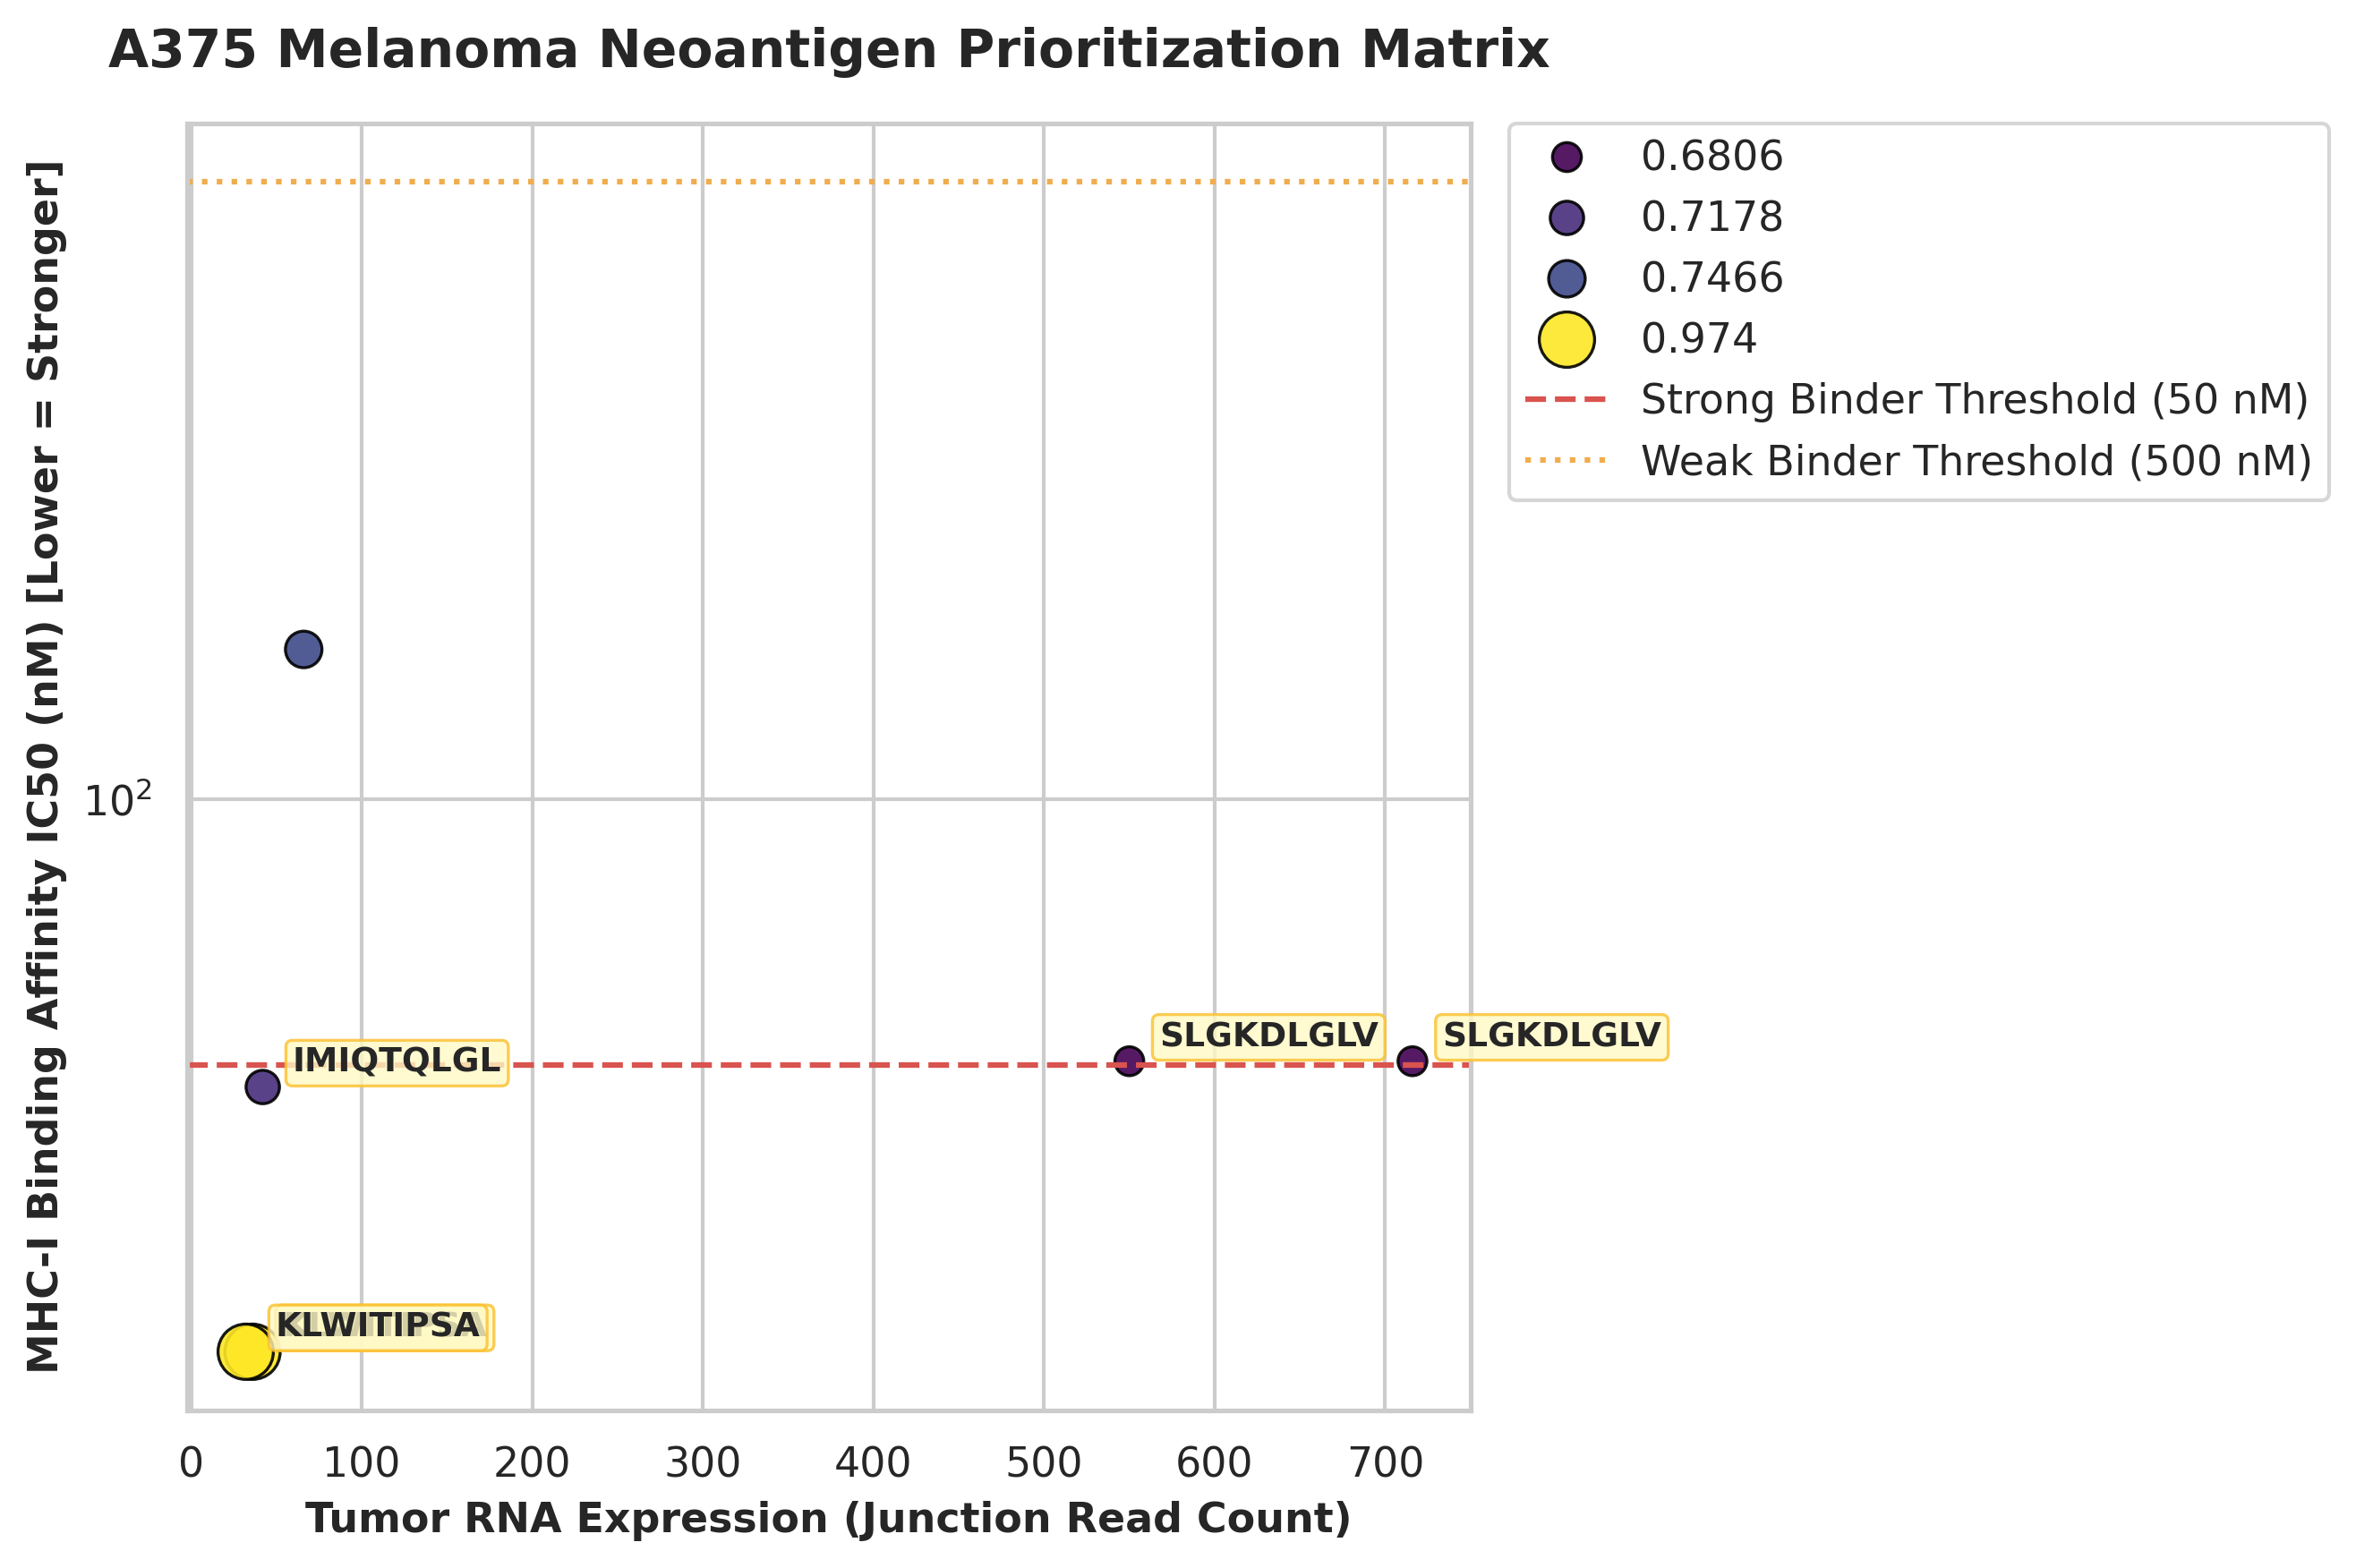

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set publication-quality aesthetics for the plot.
sns.set_theme(style="whitegrid", font="DejaVu Sans")
fig, ax = plt.subplots(figsize=(9, 6), dpi=300)

# 2. Create a scatter plot visualizing neoantigen candidates.
# X-axis: Tumor RNA Expression (Junction Read Count)
# Y-axis: MHC-I Binding Affinity (IC50) - lower is stronger
# Color and size of points represent Presentation Score.
scatter = sns.scatterplot(
    data=results_df,
    x="Tumor_Read_Count",
    y="IC50_Score",
    hue="Presentation_Score",
    size="Presentation_Score",
    sizes=(60, 220),
    palette="viridis",
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
    ax=ax
)

# 3. Add horizontal lines to indicate clinical thresholds for strong (50 nM) and weak (500 nM) binders.
ax.axhline(50, color="#d9534f", linestyle="--", linewidth=1.5, label="Strong Binder Threshold (50 nM)")
ax.axhline(500, color="#f0ad4e", linestyle=":", linewidth=1.5, label="Weak Binder Threshold (500 nM)")

# 4. Annotate top candidates (those with IC50_Score <= 100 nM) with their peptide sequences for easy identification.
for idx, row in results_df.iterrows():
    if row["IC50_Score"] <= 100:  # Highlight high-affinity candidates
        ax.annotate(
            row["Peptide"],
            (row["Tumor_Read_Count"], row["IC50_Score"]),
            textcoords="offset points",
            xytext=(8, 4),
            ha="left",
            fontsize=9,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="#fff9c4", ec="#fbc02d", lw=0.8, alpha=0.8)
        )

# 5. Format the plot title and axis labels for clarity and readability.
ax.set_title("A375 Melanoma Neoantigen Prioritization Matrix", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Tumor RNA Expression (Junction Read Count)", fontsize=11, fontweight="bold")
ax.set_ylabel("MHC-I Binding Affinity IC50 (nM) [Lower = Stronger]", fontsize=11, fontweight="bold")

# Use a logarithmic scale for the Y-axis (IC50) as values can span multiple orders of magnitude.
ax.set_yscale("log")

# 6. Adjust the legend placement and layout to prevent overlap with the plot.
ax.legend(bbox_to_anchor=(1.03, 1), loc="upper left", borderaxespad=0, frameon=True)
plt.tight_layout()

# 7. Save the generated plot as a high-resolution PNG image, suitable for publications or reports.
plt.savefig("Neoantigen_Prioritization_Scatter.png", dpi=300, bbox_inches="tight")
plt.show()